**Exercício 1 normal para 20 épocas**

Pesos iniciais: w0=-0.176, w1=0.276, w2=0.494
Epoca 1
  Entrada: (0,0) -> s=-0.176, saida=0, erro=0
  Entrada: (0,1) -> s=0.318, saida=0, erro=1
  Entrada: (1,0) -> s=0.100, saida=0, erro=1
  Entrada: (1,1) -> s=0.595, saida=1, erro=0
erro total: 2
delta_w: [0.02 0.01 0.01]
pesos atualizados: w0=-0.156, w1=0.286, w2=0.504

Epoca 2
  Entrada: (0,0) -> s=-0.156, saida=0, erro=0
  Entrada: (0,1) -> s=0.348, saida=0, erro=1
  Entrada: (1,0) -> s=0.130, saida=0, erro=1
  Entrada: (1,1) -> s=0.635, saida=1, erro=0
erro total: 2
delta_w: [0.02 0.01 0.01]
pesos atualizados: w0=-0.136, w1=0.296, w2=0.514

Epoca 3
  Entrada: (0,0) -> s=-0.136, saida=0, erro=0
  Entrada: (0,1) -> s=0.378, saida=0, erro=1
  Entrada: (1,0) -> s=0.160, saida=0, erro=1
  Entrada: (1,1) -> s=0.675, saida=1, erro=0
erro total: 2
delta_w: [0.02 0.01 0.01]
pesos atualizados: w0=-0.116, w1=0.306, w2=0.524

Epoca 4
  Entrada: (0,0) -> s=-0.116, saida=0, erro=0
  Entrada: (0,1) -> s=0.408, saida=0, erro=1
  Entrada: (1,0) -

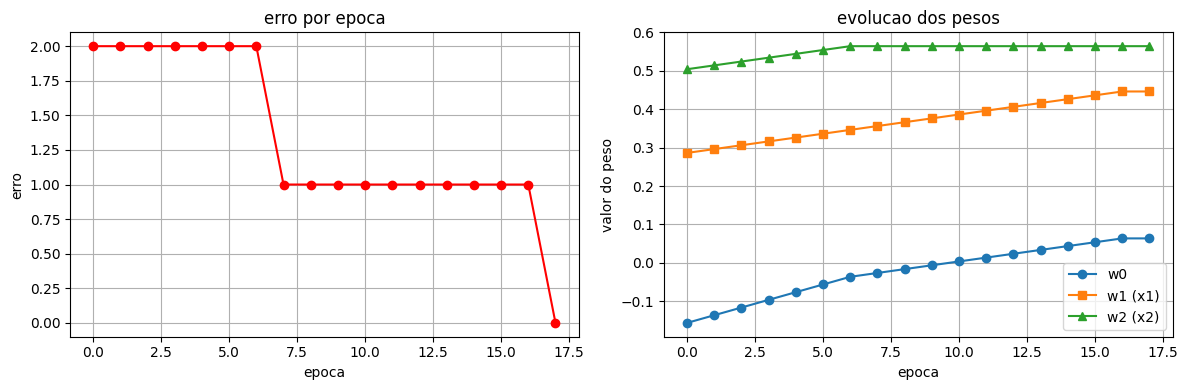

pesos finais: w0=0.063806, w1=0.446377, w2=0.564349
teste da classificacao final:
entrada: (0, 0) -> s=0.063806, saida=0 (desejado: 0)
entrada: (0, 1) -> s=0.628155, saida=1 (desejado: 1)
entrada: (1, 0) -> s=0.510183, saida=1 (desejado: 1)
entrada: (1, 1) -> s=1.074532, saida=1 (desejado: 1)
taxa de acerto: 4/4 = 100.0%
perceptrao aprendeu corretamente


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Dados OR
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
d = np.array([0, 1, 1, 1])


alpha = 0.01
epocas = 20

w = np.random.uniform(-0.5, 0.5, 3)
print(f"Pesos iniciais: w0={w[0]:.3f}, w1={w[1]:.3f}, w2={w[2]:.3f}")

errors_per_epoca = []
weights_per_epoca = []

for epoca in range(epocas):
    delta_w = np.zeros(3)  
    error_epoca = 0
    
    print(f"Epoca {epoca + 1}")
    
    for i in range(len(X)):
        x1, x2 = X[i]
        s = w[0] + w[1]*x1 + w[2]*x2
        o = 1 if s > 0.5 else 0
        e = d[i] - o
        error_epoca += abs(e)
        delta_w[0] += alpha * e
        delta_w[1] += alpha * x1 * e
        delta_w[2] += alpha * x2 * e
        
        print(f"  Entrada: ({x1},{x2}) -> s={s:.3f}, saida={o}, erro={e}")
    
    w += delta_w
    
    errors_per_epoca.append(error_epoca)
    weights_per_epoca.append(w.copy())
    
    print(f"erro total: {error_epoca}")
    print(f"delta_w: {delta_w}")
    print(f"pesos atualizados: w0={w[0]:.3f}, w1={w[1]:.3f}, w2={w[2]:.3f}")
    print("")
    
    if error_epoca == 0:
        print(f"convergiu na epoca {epoca + 1}")
        break

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(errors_per_epoca, marker='o', color='red')
plt.title('erro por epoca')
plt.xlabel('epoca')
plt.ylabel('erro')
plt.grid(True)

plt.subplot(1, 2, 2)
weights_per_epoca = np.array(weights_per_epoca)
plt.plot(weights_per_epoca[:, 0], label='w0', marker='o')
plt.plot(weights_per_epoca[:, 1], label='w1 (x1)', marker='s')
plt.plot(weights_per_epoca[:, 2], label='w2 (x2)', marker='^')
plt.title('evolucao dos pesos')
plt.xlabel('epoca')
plt.ylabel('valor do peso')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"pesos finais: w0={w[0]:.6f}, w1={w[1]:.6f}, w2={w[2]:.6f}")

print("teste da classificacao final:")
correct = 0
for i, (x1, x2) in enumerate(X):
    s_final = w[0] + w[1]*x1 + w[2]*x2
    o_final = 1 if s_final > 0.5 else 0
    print(f"entrada: ({x1}, {x2}) -> s={s_final:.6f}, saida={o_final} (desejado: {d[i]})")
    if o_final == d[i]:
        correct += 1

print(f"taxa de acerto: {correct}/4 = {correct/4*100:.1f}%")

if correct == 4:
    print("perceptrao aprendeu corretamente")
else:
    print("perceptrao nao convergiu completamente")

**Conclusões sobre a rede neuronal**


(a) Em termos da tendência do erro ao longo das épocas este começa com valores de cerca de 3, ou seja, nas primeiras épocas faz previsões erradas que geram um valor de erro significativo, após isso nas épocas intermédias, o erro cai rapidamente uma vez que o perceptrão aprende rapidamente , convergindo para um valor de erro de zero quando aprendeu perfeitamente.
(b) Os pesos w0, w1 e w2 começam com valores aleatórios, e ao fazer várias tentativas com valores diferentes, estes têm tendência a ser sempre do mesmo tipo, ou seja, estabilizam sempre em valores finais, o que demonstra que a configuração é consistente.
(c) Com a alteração do valor de alpha foi possível perceber que para um valor baixo inicial de 10e-4 o learning rate é muito lento e o erro por época não muda mantendo-se constante num valor de 3, ou seja, pode não convergiu em 20 épocas. De seguida, para um valor de 0.01 o learning rate continua a ser lento mas o valor de erro por época varia ficando com valor minimo de 1, ou seja, melhorou mas ainda não conseguiu convergir em 20 épocas. Com um valor de alpha de 0.1, o perceptrõa convergiu completamente e nem foi necessário as 20 épocas, basta entre 3 e 5 épocas para convergir, ou seja, o erro ter um valor de 0. Para valores superiores de alpha também convergem mas saõ menos estáveis uma vez que saltam valores extremos. Em suma, o melhor valor para alpha é 0.1.

**Exercício 1 - 30 repetições (d)**

In [28]:
import numpy as np

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
d = np.array([0, 1, 1, 1])
 
alpha = 0.01
epocas= 20
runs = 30

convergence_epocas = []

for run in range(runs):
    w = np.random.uniform(-0.5, 0.5, 3)
    
    for epoca in range(epocas):
        delta_w = np.zeros(3)
        error_epoca = 0
        
        for i in range(len(X)):
            x1, x2 = X[i]
            s = w[0] + w[1]*x1 + w[2]*x2
            o = 1 if s > 0.5 else 0
            e = d[i] - o
            error_epoca += abs(e)
            
            delta_w[0] += alpha * e
            delta_w[1] += alpha * x1 * e
            delta_w[2] += alpha * x2 * e
        
        w[0] += delta_w[0]
        w[1] += delta_w[1] 
        w[2] += delta_w[2]
        
        
        if error_epoca == 0:  
            convergence_epocas.append(epoca + 1)
            break
    else:
        convergence_epocas.append(epocas)


print(f"execuções: {runs}")
print(f"média: {np.mean(convergence_epocas):.2f} épocas")
print(f"desvio padrão: {np.std(convergence_epocas):.2f} épocas")
print(f"execuções que convergiram: {sum(1 for x in convergence_epocas if x < epocas)}/{runs}")

print(f"\nValores por execução: {convergence_epocas}")

execuções: 30
média: 17.97 épocas
desvio padrão: 3.71 épocas
execuções que convergiram: 12/30

Valores por execução: [20, 20, 18, 20, 20, 18, 20, 20, 20, 16, 19, 16, 20, 18, 20, 20, 20, 11, 20, 17, 20, 11, 20, 20, 4, 12, 20, 19, 20, 20]


**Distribuição Gaussiana multivariada**

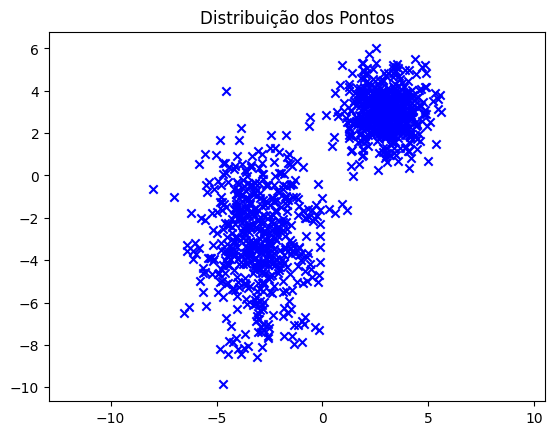

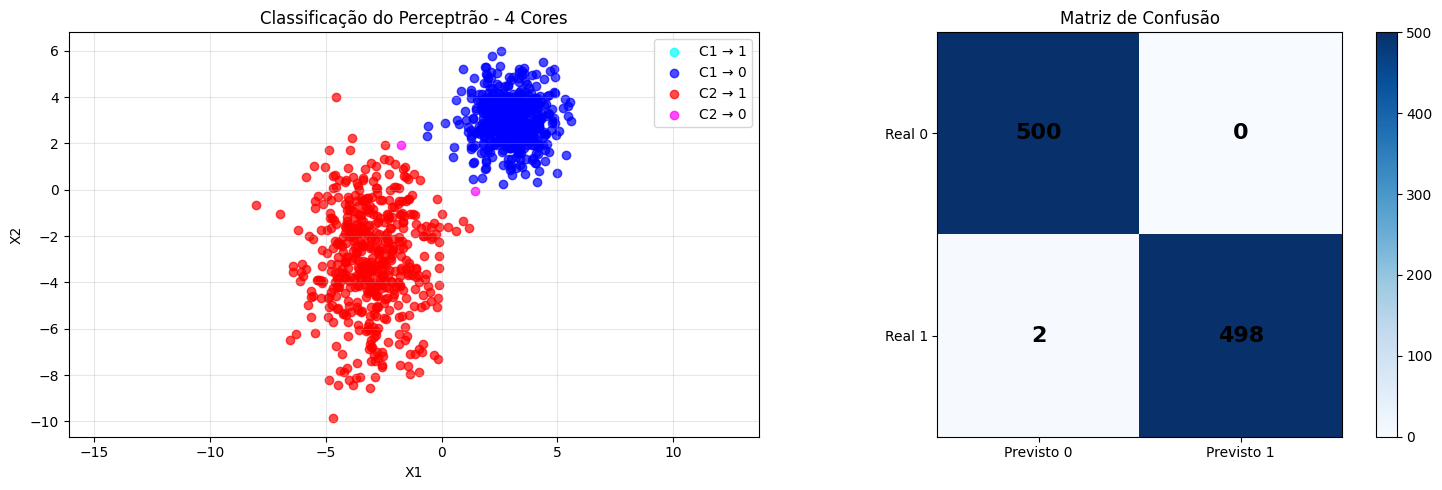


 metricas para os 30 testes
accuracy média: 0.996
precisão média: 1.000
recall médio: 0.992
f1-score médio: 0.996

matriz de Confusão Média:
verdadeiros Negativos: 500.0
falsos Positivos: 0.0
falsos Negativos: 4.0
verdadeiros Positivos: 496.0
azul (Dist1 → 0): 500 pontos → Verdadeiros Negativos
ciano (Dist1 → 1): 0 pontos → Falsos Positivos
vermelho (Dist2 → 1): 498 pontos → Verdadeiros Positivos
magenta (Dist2 → 0): 2 pontos → Falsos Negativos


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import random

mean = [3, 3]
cov = [[1 , 0], [0, 1]]
a = np.random.multivariate_normal(mean, cov, 500).T
mean = [-3, -3]
cov = [[2 , 0], [0, 5]]
b = np.random.multivariate_normal(mean, cov, 500).T
#mean = [1.5, 1.5]
#cov = [[2, 0], [0, 2]]
#a = np.random.multivariate_normal(mean, cov, 500).T

#mean = [-1.5, -1.5]
#cov = [[2, 0], [0, 2]]
#b = np.random.multivariate_normal(mean, cov, 500).T
c = np.concatenate((a, b) , axis = 1)
c = c.T
etiqueta_a = np.zeros((500, 1))  
etiqueta_b = np.ones((500, 1))   
etiquetas = np.vstack((etiqueta_a, etiqueta_b))
c = np.hstack((c, etiquetas))
np.random. shuffle(c)
c = c.T
x = c[0]
y = c[1]
etiquetas = c[2]


plt.scatter(x, y, c='blue', marker='x')
plt.axis ( 'equal' )
plt.title('Distribuição dos Pontos')
plt.show()
np.savetxt('conjunto_de_etiquetas.txt', c.T, fmt='%.3f', delimiter=',', header='x,y,etiqueta', comments='')

data = c[:2].T  
labels = c[2]   


alpha = 0.001
epocas = 10
n_tests = 30

all_accuracies = []
all_precisions = []
all_recalls = []
all_f1s = []
all_tp = []
all_fp = []
all_tn = []
all_fn = []
all_convergence_epochs = []  

for test in range(n_tests):
    w = np.random.uniform(-0.5, 0.5, 3)
    
    converged = False
    for epoca in range(epocas):
        delta_w = np.zeros(3)  
        total_error = 0
        
        for i in range(len(data)):
            x1, x2 = data[i]
            s = w[0] + w[1]*x1 + w[2]*x2
            o = 1 if s > 0.5 else 0
            e = labels[i] - o
            total_error += abs(e)
            
            delta_w[0] += alpha * e
            delta_w[1] += alpha * x1 * e
            delta_w[2] += alpha * x2 * e
        
        w[0] += delta_w[0]
        w[1] += delta_w[1]
        w[2] += delta_w[2]
        
    
    predictions = []
    for i in range(len(data)):
        x1, x2 = data[i]
        s = w[0] + w[1]*x1 + w[2]*x2
        o = 1 if s > 0.5 else 0
        predictions.append(o)
    
    predictions = np.array(predictions)
    
    tn = np.sum((labels == 0) & (predictions == 0))
    fp = np.sum((labels == 0) & (predictions == 1))
    fn = np.sum((labels == 1) & (predictions == 0))
    tp = np.sum((labels == 1) & (predictions == 1))
    
    accuracy = (tp + tn) / len(labels)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    all_accuracies.append(accuracy)
    all_precisions.append(precision)
    all_recalls.append(recall)
    all_f1s.append(f1)
    all_tp.append(tp)
    all_fp.append(fp)
    all_tn.append(tn)
    all_fn.append(fn)
    
    if test == 0:
        first_predictions = predictions
        first_w = w.copy()



mask_a = (labels == 0) & (first_predictions == 1)  # Dist1 → 1
mask_b = (labels == 0) & (first_predictions == 0)  # Dist1 → 0
mask_c = (labels == 1) & (first_predictions == 1)  # Dist2 → 1
mask_d = (labels == 1) & (first_predictions == 0)  # Dist2 → 0

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(data[mask_a, 0], data[mask_a, 1], c='cyan', alpha=0.7, label='C1 → 1')
plt.scatter(data[mask_b, 0], data[mask_b, 1], c='blue', alpha=0.7, label='C1 → 0')
plt.scatter(data[mask_c, 0], data[mask_c, 1], c='red', alpha=0.7, label='C2 → 1')
plt.scatter(data[mask_d, 0], data[mask_d, 1], c='magenta', alpha=0.7, label='C2 → 0')

plt.title('Classificação do Perceptrão - 4 Cores')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')




plt.subplot(1, 2, 2)
tn_first = np.sum(mask_b)
fp_first = np.sum(mask_a)
fn_first = np.sum(mask_d)
tp_first = np.sum(mask_c)

confusion_matrix = np.array([[tn_first, fp_first], [fn_first, tp_first]])


plt.imshow(confusion_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(confusion_matrix[i, j]), 
                ha='center', va='center', fontsize=16, fontweight='bold')

plt.xticks([0, 1], ['Previsto 0', 'Previsto 1'])
plt.yticks([0, 1], ['Real 0', 'Real 1'])
plt.title('Matriz de Confusão')

plt.tight_layout()
plt.show()



print("\n metricas para os 30 testes")

avg_accuracy = np.mean(all_accuracies)
avg_precision = np.mean(all_precisions)
avg_recall = np.mean(all_recalls)
avg_f1 = np.mean(all_f1s)

avg_tp = np.mean(all_tp)
avg_fp = np.mean(all_fp)
avg_tn = np.mean(all_tn)
avg_fn = np.mean(all_fn)

print(f"accuracy média: {avg_accuracy:.3f}")
print(f"precisão média: {avg_precision:.3f}")
print(f"recall médio: {avg_recall:.3f}")
print(f"f1-score médio: {avg_f1:.3f}")

print(f"\nmatriz de Confusão Média:")
print(f"verdadeiros Negativos: {avg_tn:.1f}")
print(f"falsos Positivos: {avg_fp:.1f}")
print(f"falsos Negativos: {avg_fn:.1f}")
print(f"verdadeiros Positivos: {avg_tp:.1f}")

print(f"azul (Dist1 → 0): {tn_first} pontos → Verdadeiros Negativos")
print(f"ciano (Dist1 → 1): {fp_first} pontos → Falsos Positivos") 
print(f"vermelho (Dist2 → 1): {tp_first} pontos → Verdadeiros Positivos")
print(f"magenta (Dist2 → 0): {fn_first} pontos → Falsos Negativos")





**Exercício 2**

C:\Users\André\AppData\Local\Temp\ipykernel_11128\4041401610.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([resultados[3]['accuracy'], resultados[7]['accuracy'], resultados[11]['accuracy']],


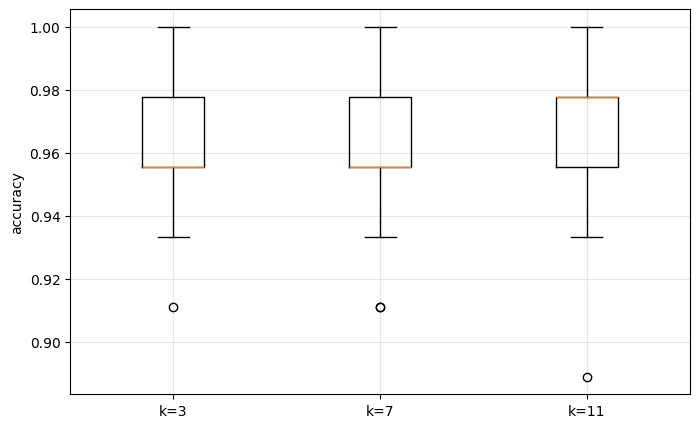

C:\Users\André\AppData\Local\Temp\ipykernel_11128\4041401610.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([resultados[3]['precisao'], resultados[7]['precisao'], resultados[11]['precisao']],


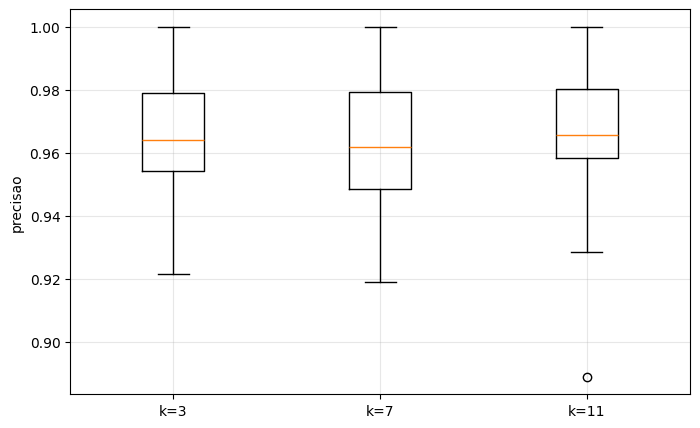

C:\Users\André\AppData\Local\Temp\ipykernel_11128\4041401610.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([resultados[3]['recall'], resultados[7]['recall'], resultados[11]['recall']],


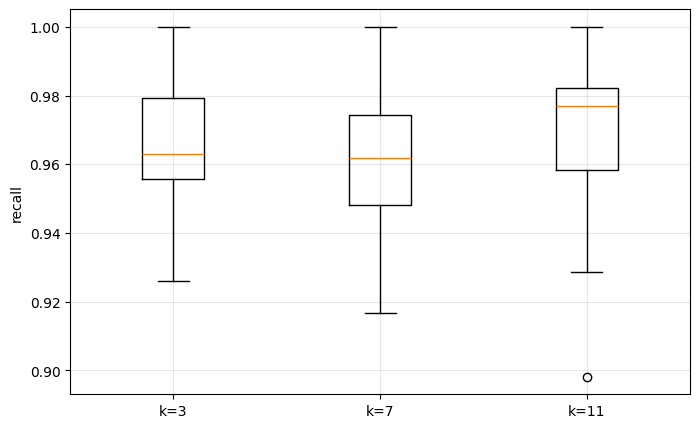

C:\Users\André\AppData\Local\Temp\ipykernel_11128\4041401610.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([resultados[3]['f1'], resultados[7]['f1'], resultados[11]['f1']],


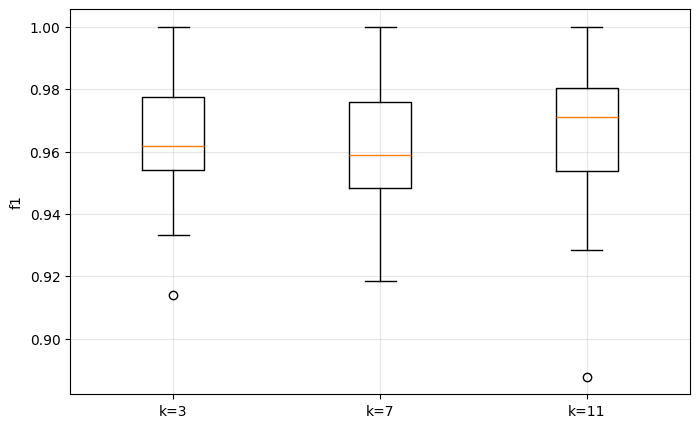


 metricas da 30 execucoes

--- k = 3 ---
accuracy média: 0.966
precisão média: 0.966
recall médio: 0.967
f1-score médio: 0.966

--- k = 7 ---
accuracy média: 0.961
precisão média: 0.963
recall médio: 0.961
f1-score médio: 0.961

--- k = 11 ---
accuracy média: 0.968
precisão média: 0.967
recall médio: 0.970
f1-score médio: 0.967

matriz de confusao


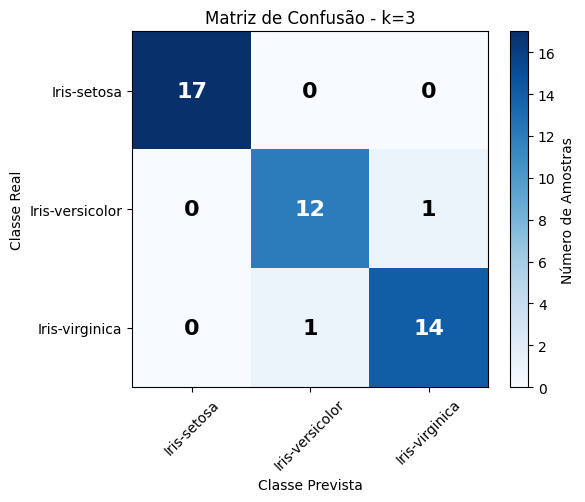

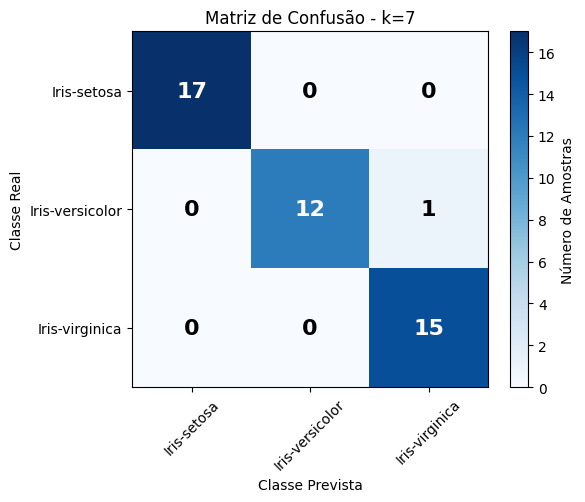

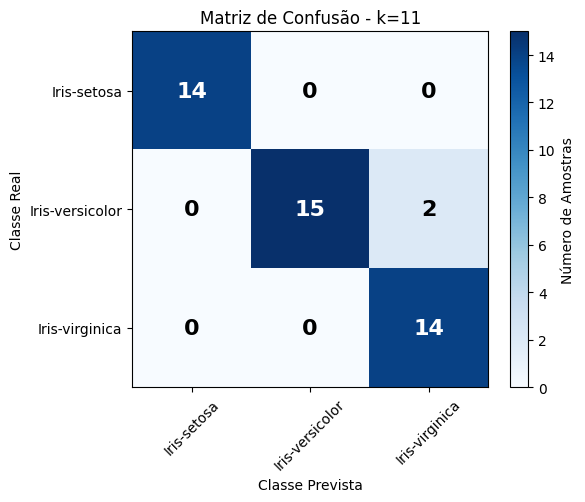

In [27]:
dados = np.loadtxt('iris.data', delimiter=',', dtype=str)
X = dados[:, :4].astype(float)
y_texto = dados[:, 4]

classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
y = np.array([classes.index(classe) for classe in y_texto])

k_valores = [3, 7, 11]
resultados = {k: {'accuracy': [], 'precisao': [], 'recall': [], 'f1': []} for k in k_valores}
matrizes = {}

for k in k_valores:
    for execucao in range(30):
        indices = np.random.permutation(len(X))
        n_treino = int(0.7 * len(X))
    
        treino_idx = indices[:n_treino]
        teste_idx = indices[n_treino:]  
        
        X_treino, X_teste = X[treino_idx], X[teste_idx]
        y_treino, y_teste = y[treino_idx], y[teste_idx]
        
        predictions = []
        for ponto in X_teste:
            distancias = []
            for i in range(len(X_treino)):
                dist = np.sqrt(np.sum((ponto - X_treino[i]) ** 2))
                distancias.append((dist, y_treino[i]))
            
            distancias.sort(key=lambda x: x[0])
            vizinhos = [classe for (_, classe) in distancias[:k]]
            
            contagem = [0, 0, 0]
            for vizinho in vizinhos:
                contagem[vizinho] += 1

            predictions.append(contagem.index(max(contagem)))
        
        predictions = np.array(predictions)
        accuracy = np.mean(predictions == y_teste)
        precisao_classe = []
        recall_classe = []
        f1_classe = []
        
        for classe in range(3):
            tp = np.sum((y_teste == classe) & (predictions == classe))
            fp = np.sum((y_teste != classe) & (predictions == classe))
            fn = np.sum((y_teste == classe) & (predictions != classe))
            
            precisao = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precisao * recall) / (precisao + recall) if (precisao + recall) > 0 else 0
            
            precisao_classe.append(precisao)
            recall_classe.append(recall)
            f1_classe.append(f1)
        

        precisao_media = np.mean(precisao_classe)
        recall_medio = np.mean(recall_classe)
        f1_medio = np.mean(f1_classe)
        
        resultados[k]['accuracy'].append(accuracy)
        resultados[k]['precisao'].append(precisao_media)
        resultados[k]['recall'].append(recall_medio)
        resultados[k]['f1'].append(f1_medio)
        
        if execucao == 0:
            cm = [[0,0,0], [0,0,0], [0,0,0]]
            for i in range(len(y_teste)):
                real = y_teste[i]
                pred = predictions[i]
                cm[real][pred] += 1
            matrizes[k] = cm

plt.figure(figsize=(8, 5))
plt.boxplot([resultados[3]['accuracy'], resultados[7]['accuracy'], resultados[11]['accuracy']], 
            labels=['k=3', 'k=7', 'k=11'])
plt.ylabel('accuracy')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot([resultados[3]['precisao'], resultados[7]['precisao'], resultados[11]['precisao']], 
            labels=['k=3', 'k=7', 'k=11'])
plt.ylabel('precisao')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot([resultados[3]['recall'], resultados[7]['recall'], resultados[11]['recall']], 
            labels=['k=3', 'k=7', 'k=11'])
plt.ylabel('recall')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot([resultados[3]['f1'], resultados[7]['f1'], resultados[11]['f1']], 
            labels=['k=3', 'k=7', 'k=11'])
plt.ylabel('f1')
plt.grid(True, alpha=0.3)
plt.show()


print("\n metricas da 30 execucoes")
for k in k_valores:
    print(f"\n--- k = {k} ---")
    print(f"accuracy média: {np.mean(resultados[k]['accuracy']):.3f}")
    print(f"precisão média: {np.mean(resultados[k]['precisao']):.3f}")
    print(f"recall médio: {np.mean(resultados[k]['recall']):.3f}")
    print(f"f1-score médio: {np.mean(resultados[k]['f1']):.3f}")


print("\nmatriz de confusao")
for k in k_valores:
    cm = matrizes[k]
    
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues', interpolation='nearest')
    
    for i in range(3):
        for j in range(3):
            plt.text(j, i, str(cm[i][j]), 
                    ha='center', va='center', 
                    fontsize=16, fontweight='bold',
                    color='white' if cm[i][j] > max(max(row) for row in cm)/2 else 'black')
    
    plt.xticks([0, 1, 2], classes, rotation=45)
    plt.yticks([0, 1, 2], classes)
    plt.xlabel('Classe Prevista')
    plt.ylabel('Classe Real')
    plt.title(f'Matriz de Confusão - k={k}')
    plt.colorbar(label='Número de Amostras')
    plt.tight_layout()
    plt.show()

**Impar ou par k-NN**


O k-NN consiste na classificação de uma classe através da classe maioritária entre os k vizinhos, por outras palavras um k par pode resultar num empate uma vez que pode haver 2 vizinhos de cada classe num caso de k=4, o que torna impossível determinar a classe em estudo. Por outro lado, com k impar haverá sempre uma classe que se destaca, garantindo que a decisão seja concisa para cada ponto de teste.

**Exercício 3**

discretização: 0=low, 1=medium, 2=high

 resultados de (30 execucoes)
accuracy:  0.941 
precisão:  0.942 
recall:    0.941 
f1-Score:  0.939

 matriz de confusão


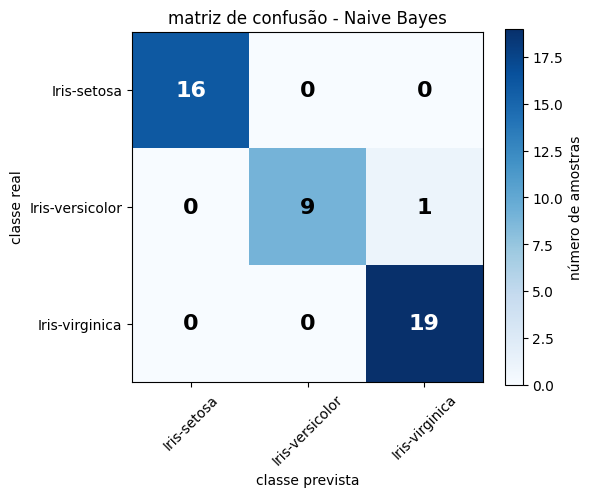

In [24]:
dados = np.loadtxt('iris.data', delimiter=',', dtype=str)
X = dados[:, :4].astype(float)
y_texto = dados[:, 4]

classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
y = np.array([classes.index(c) for c in y_texto])
n_classes = len(classes)

X_disc = np.zeros_like(X, dtype=int)  

for col in range(X.shape[1]):
    valores = X[:, col]
    low = np.percentile(valores, 33)
    high = np.percentile(valores, 66)
    
    for i in range(len(valores)):
        if valores[i] <= low:
            X_disc[i, col] = 0  
        elif valores[i] <= high:
            X_disc[i, col] = 1  
        else:
            X_disc[i, col] = 2  

print("discretização: 0=low, 1=medium, 2=high")

n_execucoes = 30
acuracias = []
precisoes = []
recalls = []
f1_scores = []
matriz_confusao_exemplo = None

for execucao in range(n_execucoes):
    indices = np.random.permutation(len(X))
    n_treino = int(0.7 * len(X))
    
    treino_idx = indices[:n_treino]
    teste_idx = indices[n_treino:]
    
    X_treino, X_teste = X_disc[treino_idx], X_disc[teste_idx]
    y_treino, y_teste = y[treino_idx], y[teste_idx]
    
    
    prior = np.zeros(n_classes)
    for c in range(n_classes):
        prior[c] = np.sum(y_treino == c) / len(y_treino)
    
    likelihood = np.zeros((n_classes, 4, 3))  
    
    for c in range(n_classes):
        mask = (y_treino == c)
        X_classe = X_treino[mask]
        n_classe = len(X_classe)
        
        for feature in range(4):
            for categoria in range(3):
                count = np.sum(X_classe[:, feature] == categoria)
                likelihood[c, feature, categoria] = (count + 1) / (n_classe + 3)
    
    predictions = []
    for i in range(len(X_teste)):
        ponto = X_teste[i]
        probs = np.zeros(n_classes)
        
        for c in range(n_classes):
            prob = prior[c]
            for feature in range(4):
                categoria = ponto[feature]
                prob *= likelihood[c, feature, categoria]
            probs[c] = prob
        
        predictions.append(np.argmax(probs))
    
    predictions = np.array(predictions)
    
    
    accuracy = np.mean(predictions == y_teste)
    acuracias.append(accuracy)
    
    prec_classe = []
    rec_classe = []
    f1_classe = []
    
    for c in range(n_classes):
        tp = np.sum((y_teste == c) & (predictions == c))
        fp = np.sum((y_teste != c) & (predictions == c))
        fn = np.sum((y_teste == c) & (predictions != c))
        
        precisao = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precisao * recall) / (precisao + recall) if (precisao + recall) > 0 else 0
        
        prec_classe.append(precisao)
        rec_classe.append(recall)
        f1_classe.append(f1)
    
    precisoes.append(np.mean(prec_classe))
    recalls.append(np.mean(rec_classe))
    f1_scores.append(np.mean(f1_classe))
    
    if execucao == 0:
        matriz_confusao_exemplo = np.zeros((n_classes, n_classes), dtype=int)
        for i in range(len(y_teste)):
            real = y_teste[i]
            pred = predictions[i]
            matriz_confusao_exemplo[real, pred] += 1

print(f"\n resultados de ({n_execucoes} execucoes)")
print(f"accuracy:  {np.mean(acuracias):.3f} ")
print(f"precisão:  {np.mean(precisoes):.3f} ")
print(f"recall:    {np.mean(recalls):.3f} ")
print(f"f1-Score:  {np.mean(f1_scores):.3f}")

print("\n matriz de confusão")

plt.figure(figsize=(6, 5))
plt.imshow(matriz_confusao_exemplo, cmap='Blues', interpolation='nearest')

for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, str(matriz_confusao_exemplo[i, j]), 
                ha='center', va='center', 
                fontsize=16, fontweight='bold',
                color='white' if matriz_confusao_exemplo[i, j] > np.max(matriz_confusao_exemplo)/2 else 'black')

plt.xticks(range(n_classes), classes, rotation=45)
plt.yticks(range(n_classes), classes)
plt.xlabel('classe prevista')
plt.ylabel('classe real')
plt.title('matriz de confusão - Naive Bayes')
plt.colorbar(label='número de amostras')
plt.tight_layout()
plt.show()



Ao comparar os dois algoritmos em estudo percebeu-se que k-NN é do tipo baseado em distâncias enquanto que o Naive Bayes usa probabilidades.Para além disso, em termos dos resultados obtidos o k-NN para um k=3 destacou-se em comparação ao Naive Bayes, uma vez que este usa os dados originais e o Naive Bayes usa dados discretizados, causando alguma perda de informação e resultando num valor mais favorável das metricas no k-NN.

**Exercício 4**

In [23]:
from math import log2

dados = np.loadtxt('iris.data', delimiter=',', dtype=str)
X = dados[:, :4].astype(float)
y_texto = dados[:, 4]

y_binario = np.array([1 if 'setosa' in y else 0 for y in y_texto])
p_total = np.sum(y_binario == 1) / len(y_binario)
if p_total == 0 or p_total == 1:
    entropia_S = 0
else:
    entropia_S = -p_total * log2(p_total) - (1 - p_total) * log2(1 - p_total)

print(f"p+ = {np.sum(y_binario == 1)}/{len(y_binario)} = {p_total:.3f}")
print(f"entropy(S) = {entropia_S:.4f}\n")

ganhos = []

for feature_idx in range(4):
    coluna = X[:, feature_idx]
    q1 = np.percentile(coluna, 33)
    q2 = np.percentile(coluna, 67)
    
    coluna_disc = []
    for valor in coluna:
        if valor <= q1:
            coluna_disc.append('Low')
        elif valor <= q2:
            coluna_disc.append('Medium')
        else:
            coluna_disc.append('High')
    
    entropia_ponderada = 0
    detalhes = []
    
    for valor in ['Low', 'Medium', 'High']:
        indices = [i for i, v in enumerate(coluna_disc) if v == valor]
        subset_y = y_binario[indices]
        
        if len(subset_y) == 0:
            p_subset = 0
            entropia_subset = 0
        else:
            p_subset = np.sum(subset_y == 1) / len(subset_y)
            if p_subset == 0 or p_subset == 1:
                entropia_subset = 0
            else:
                entropia_subset = -p_subset * log2(p_subset) - (1 - p_subset) * log2(1 - p_subset)
        
        peso = len(subset_y) / len(y_binario)
        entropia_ponderada += peso * entropia_subset
        detalhes.append(f"{valor}: {np.sum(subset_y == 1)}/{len(subset_y)} setosa (entropy={entropia_subset:.3f})")
    
    ganho = entropia_S - entropia_ponderada
    ganhos.append(ganho)
    
    print(f"FEATURE {feature_idx+1}:")
    print(f"  Distribuição: {', '.join(detalhes)}")
    print(f"  gain = {entropia_S:.4f} - {entropia_ponderada:.4f} = {ganho:.4f}\n")

melhor_idx = np.argmax(ganhos)

print(f"feature com maior ganho: (gain = {ganhos[melhor_idx]:.4f})")



p+ = 50/150 = 0.333
entropy(S) = 0.9183

FEATURE 1:
  Distribuição: Low: 45/52 setosa (entropy=0.570), Medium: 5/56 setosa (entropy=0.434), High: 0/42 setosa (entropy=0.000)
  gain = 0.9183 - 0.3596 = 0.5587

FEATURE 2:
  Distribuição: Low: 2/57 setosa (entropy=0.219), Medium: 16/51 setosa (entropy=0.897), High: 32/42 setosa (entropy=0.792)
  gain = 0.9183 - 0.6102 = 0.3081

FEATURE 3:
  Distribuição: Low: 50/50 setosa (entropy=0.000), Medium: 0/54 setosa (entropy=0.000), High: 0/46 setosa (entropy=0.000)
  gain = 0.9183 - 0.0000 = 0.9183

FEATURE 4:
  Distribuição: Low: 50/50 setosa (entropy=0.000), Medium: 0/52 setosa (entropy=0.000), High: 0/48 setosa (entropy=0.000)
  gain = 0.9183 - 0.0000 = 0.9183

feature com maior ganho: (gain = 0.9183)


(2) e (3) Em relação ao valor do ganho para cada partição, é possível perceber que o maior valor do ganho representará um melhor valor para raiz do conjunto (para classificar). Assim, ao fazer a partição é possível reduzir as impurezas do conjunto.

(4) Em relação à formação da árvore de decisão tal como dito na alínea (3) a feature com maior ganho será a raiz do conjunto, em relação às outras features teremos de fazer novamente um cálculo das entropias e consequentemente do ganho para continuar a classificação.